# dxg Cl comparison: Ryan vs Haochen

Overlays $\ell C_\ell$ from both codes, one figure per redshift, plotted inline.
Each code uses **its own** parameters where they differ; common params are shared.
A single fitted scale factor absorbs the unit-convention difference.

Run **Setup** once, then run the overlay cell. Edit params / redshifts freely.

## Setup (run once)

In [2]:
%matplotlib inline
import numpy as np
import h5py, glob, os
import matplotlib.pyplot as plt
import mcmcfit as mf      # Haochen (optimized)
import ryan_cl as rc      # Ryan (extracted)


DATA_DIR = "../../dxg_measurement"
FRB_CATALOG = None         # path to cat_II_..._inclusion.h5, or None for stand-in

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.h5")))
assert len(FILES) == 5, f"expected 5, found {len(FILES)}: {FILES}"
if FRB_CATALOG:
    with h5py.File(FRB_CATALOG, "r") as fh:
        dm_select = fh["dm_od"][:] + fh["dm_ave"][()]
else:
    dm_select = np.random.default_rng(0).normal(500, 200, 500)
    print("WARNING: stand-in dm_select.")
g = mf.cl_Dg_fit(dm_select)
g.read_data(FILES, FILES)
print("Loaded. z bins =", list(g.zs))

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Loaded. z bins = [np.float64(0.07500000000000001), np.float64(0.15000000000000002), np.float64(0.25), np.float64(0.35), np.float64(0.45)]


## Parameters

Each code uses its OWN value where they differ:
- ALPHA: Haochen -1.5, Ryan 0.1
- b_g: Haochen per-z-bin, Ryan 1.2
- log_k_cut: Haochen cut_scale=-1, Ryan ln(1.65)
- host DM: Haochen DM_H_bar=60/DM_MWH=80, Ryan mu_host=100

Common: zstar=1, b_f=1.5, l_cut=4000, b_e=1.

In [3]:
# Haochen theta_init: DM_H_bar, cut_scale, l_cut, bf0, ALPHA, Z_STAR
h_params = (60.0, -1.0, 4000.0, 1.5, -1.5, 1.0)
RYAN_L_CUT = 4000.0     # common l_cut for Ryan's beam
ells = np.geomspace(25, g.lmax, 120)

## Overlay — one figure per redshift (inline)

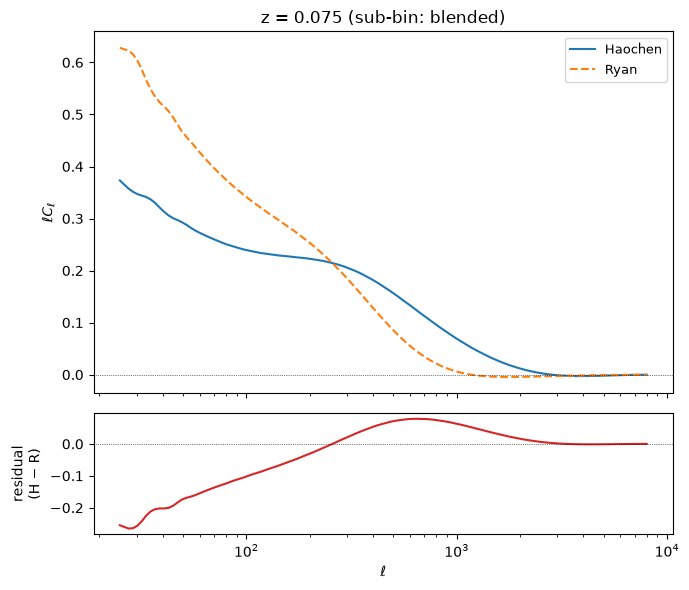

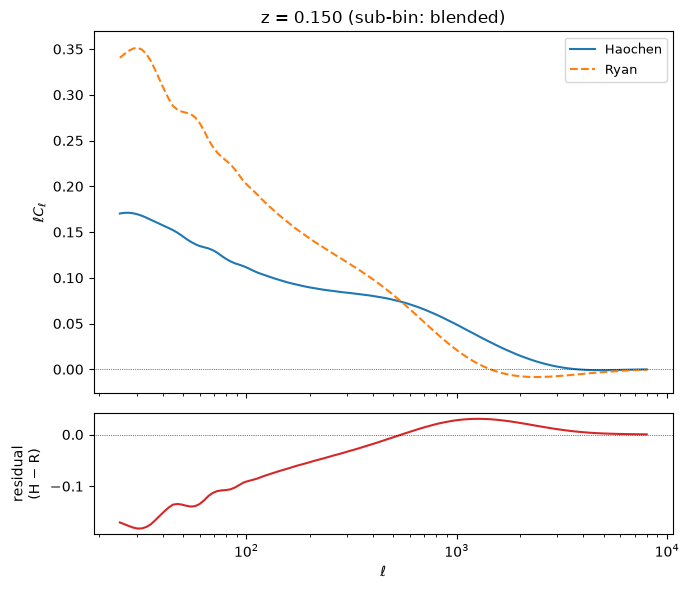

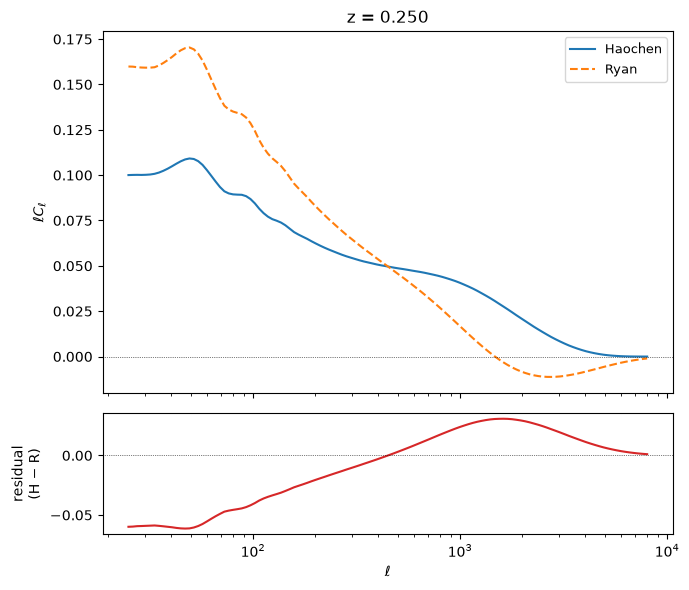

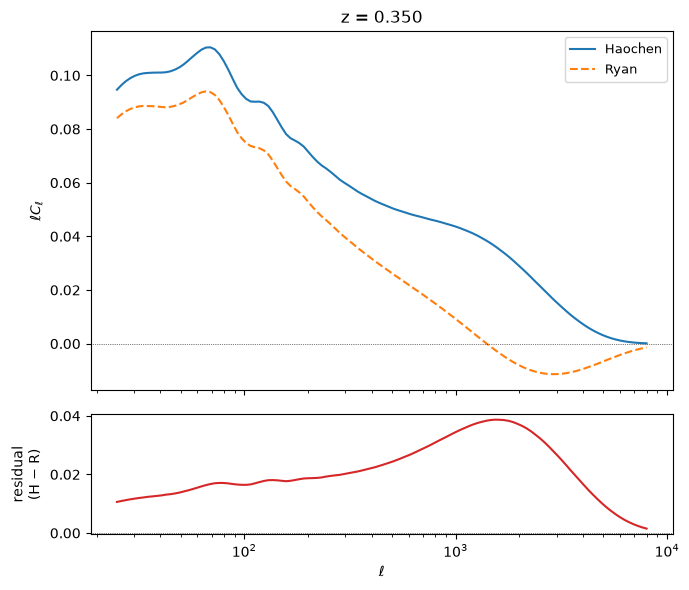

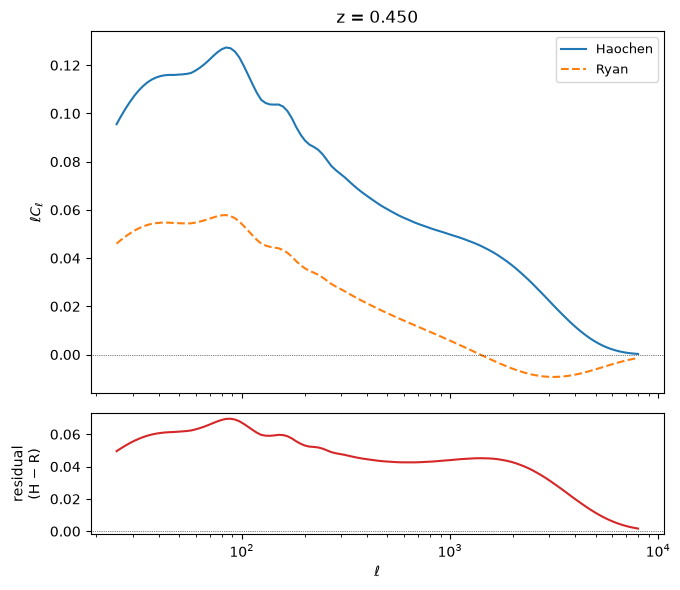

In [5]:
SUB_BIN = list(getattr(g, "sub_bin", [False]*len(g.zs)))

for zi, z_g in enumerate(g.zs):
    l_full = np.linspace(1, g.lmax, g.lmax)
    cl_h_full, _, _ = g.model_cl_Dg_plot(l_full, zi, *h_params)
    cl_h = np.interp(ells, l_full, cl_h_full)
    cl_r = np.array([rc.cl_model(e, rc.Dxg(e, z_g=z_g), l_cut=RYAN_L_CUT) for e in ells])

    h, r = ells*cl_h, ells*cl_r
    resid = h - r
    tag = " (sub-bin: blended)" if SUB_BIN[zi] else ""

    fig, (axov, axres) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                                      gridspec_kw={"height_ratios": [3, 1]})
    axov.plot(ells, h, label="Haochen")
    axov.plot(ells, r, '--', label="Ryan")
    axov.set_xscale("log")
    axov.axhline(0, color='k', lw=0.5, ls=':')
    axov.set_ylabel(r"$\ell C_\ell$")
    axov.set_title(f"z = {z_g:.3f}{tag}")
    axov.legend(fontsize=9)

    axres.plot(ells, resid, color='tab:red')
    axres.axhline(0, color='k', lw=0.5, ls=':')
    axres.set_xscale("log")
    axres.set_xlabel(r"$\ell$")
    axres.set_ylabel("residual\n(H $-$ R)")

    plt.tight_layout()
    plt.show()

## Optional: shape-only overlay (normalized, no scale fit)
Quick visual of whether the shapes match, ignoring amplitude entirely.

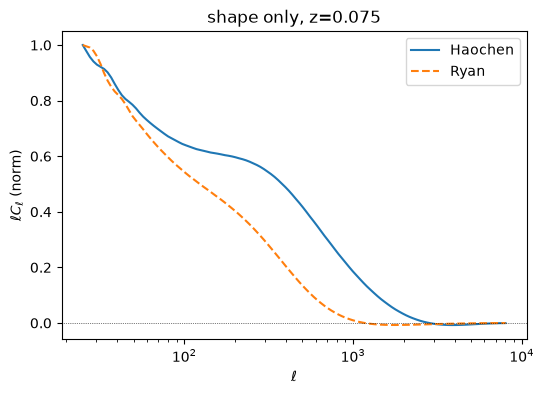

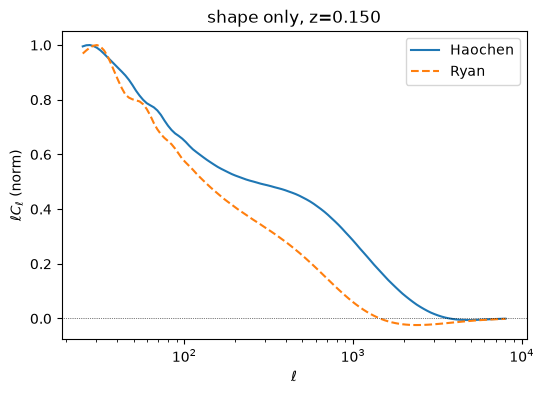

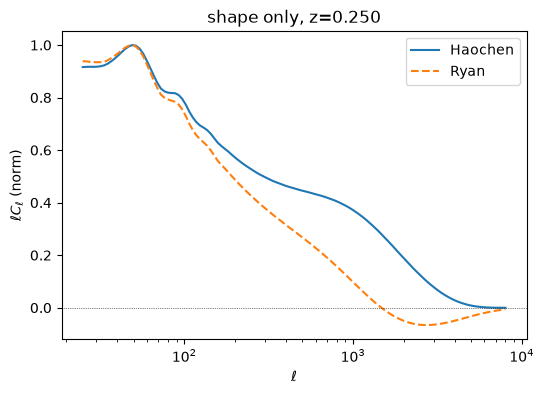

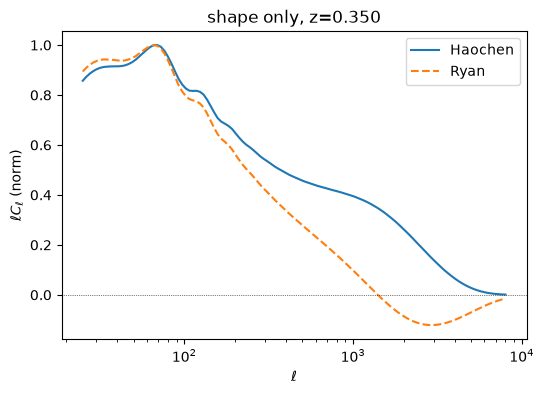

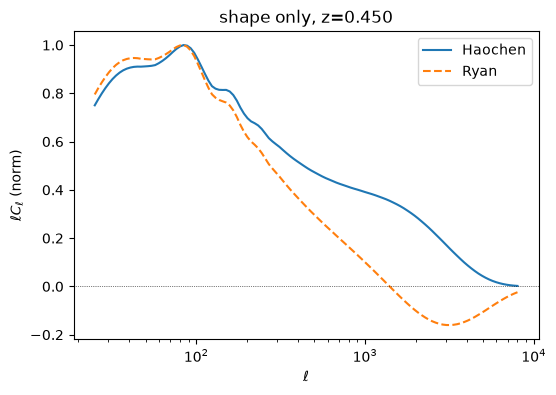

In [6]:
for zi, z_g in enumerate(g.zs):
    l_full = np.linspace(1, g.lmax, g.lmax)
    cl_h_full, _, _ = g.model_cl_Dg_plot(l_full, zi, *h_params)
    cl_h = np.interp(ells, l_full, cl_h_full)
    cl_r = np.array([rc.cl_model(e, rc.Dxg(e, z_g=z_g), l_cut=RYAN_L_CUT) for e in ells])
    h, r = ells*cl_h, ells*cl_r
    plt.figure(figsize=(6,4))
    plt.plot(ells, h/np.max(np.abs(h)), label="Haochen")
    plt.plot(ells, r/np.max(np.abs(r)), '--', label="Ryan")
    plt.xscale("log"); plt.axhline(0, color='k', lw=0.5, ls=':')
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell C_\ell$ (norm)")
    plt.title(f"shape only, z={z_g:.3f}"); plt.legend(); plt.show()